<a href="https://colab.research.google.com/github/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/blob/main/Assignment%204/%20Assignment_4_The_Predictive_Architecture.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install category_encoders missingno


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.6 MB/s eta 0:00:00


In [ ]:

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.eval_measures import rmse
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
"""
OMITTED CONFOUNDER: Socioeconomic Status / Systemic Poverty

DAG — Fork Structure:
                Socioeconomic Status (Confounder Z)
               /                                   \\
              v                                     v
  High_Deductible_Insurance_Plan          Inpatient_Admission_Rate
  (Treatment / Exposure X)                (Outcome Y)

Explanation:
- Low-income / high-poverty patients are simultaneously MORE likely to
  (a) hold high-deductible plans (cheaper premiums, limited employer
      benefits) and
  (b) be admitted as inpatients (worse baseline health, deferred care,
      nutritional deficiencies, occupational hazards).
- The confounder Z opens a "back-door path" X ← Z → Y.
- Running OLS of Y on X WITHOUT controlling for Z forces the model to
  attribute Z's effect onto the X coefficient, inflating (biasing) it.
  The estimated β̂_X absorbs both the true direct effect of insurance
  type AND the indirect poverty pathway — making it mathematically
  contaminated and causally uninterpretable.
- Marketing's causal claim (high-deductible plans CAUSE more admissions)
  is therefore spurious; it is poverty driving both variables.
"""
print("=" * 60)
print("STEP 1.1 — DAG Explanation printed above as docstring.")
print("=" * 60)

STEP 1.1 — DAG Explanation printed above as docstring.


In [ ]:
vitals = pd.read_csv('https://raw.githubusercontent.com/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Clinical_Vitals.csv')
print("\nVitals dataset shape:", vitals.shape)
print(vitals.head())

vif_cols = ["Weight_kg", "Height_cm", "BMI", "Systolic_BP", "Diastolic_BP"]

def compute_vif(df, cols):
    X = df[cols].dropna()
    X_const = sm.add_constant(X)
    vif_data = pd.DataFrame({
        "Feature": cols,
        "VIF": [variance_inflation_factor(X_const.values, i + 1)
                for i in range(len(cols))]
    }).sort_values("VIF", ascending=False).reset_index(drop=True)
    return vif_data

print("\n--- Initial VIF Matrix ---")
vif_initial = compute_vif(vitals, vif_cols)
print(vif_initial)

# BMI = weight / height², so it is a deterministic linear combination
# of Weight_kg and Height_cm → expect VIF >> 10 for BMI.
# Drop BMI as the most redundant variable.
print("\n>>> Variables with VIF > 10 are multicollinear.")
print(">>> Dropping 'BMI' (mathematically derived from Weight & Height).")

vif_cols_reduced = ["Weight_kg", "Height_cm", "Systolic_BP", "Diastolic_BP"]
print("\n--- Reduced VIF Matrix (after dropping BMI) ---")
vif_reduced = compute_vif(vitals, vif_cols_reduced)
print(vif_reduced)
print("\nAll remaining VIFs should be below 10 —> structural stability confirmed.")




Vitals dataset shape: (5000, 6)
   Patient_ID  Height_cm  Weight_kg    BMI  Systolic_BP  Diastolic_BP
0        1000      177.5       66.3  21.06        110.0          75.0
1        1001      167.9       57.5  20.39        115.0          79.0
2        1002      179.7       57.4  17.77        111.0          77.0
3        1003      192.8       80.9  21.76        122.0          88.0
4        1004      166.5       65.7  23.70        138.0          89.0

--- Initial VIF Matrix ---
        Feature        VIF
0     Weight_kg  57.428058
1     Height_cm  28.419446
2           BMI  16.981232
3  Diastolic_BP   4.219820
4   Systolic_BP   4.219406

>>> Variables with VIF > 10 are multicollinear.
>>> Dropping 'BMI' (mathematically derived from Weight & Height).

--- Reduced VIF Matrix (after dropping BMI) ---
        Feature       VIF
0  Diastolic_BP  4.219820
1   Systolic_BP  4.219406
2     Weight_kg  3.763969
3     Height_cm  3.763812

All remaining VIFs should be below 10 —> structural stability 

/tmp/ipykernel_256/3012929787.py:5: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


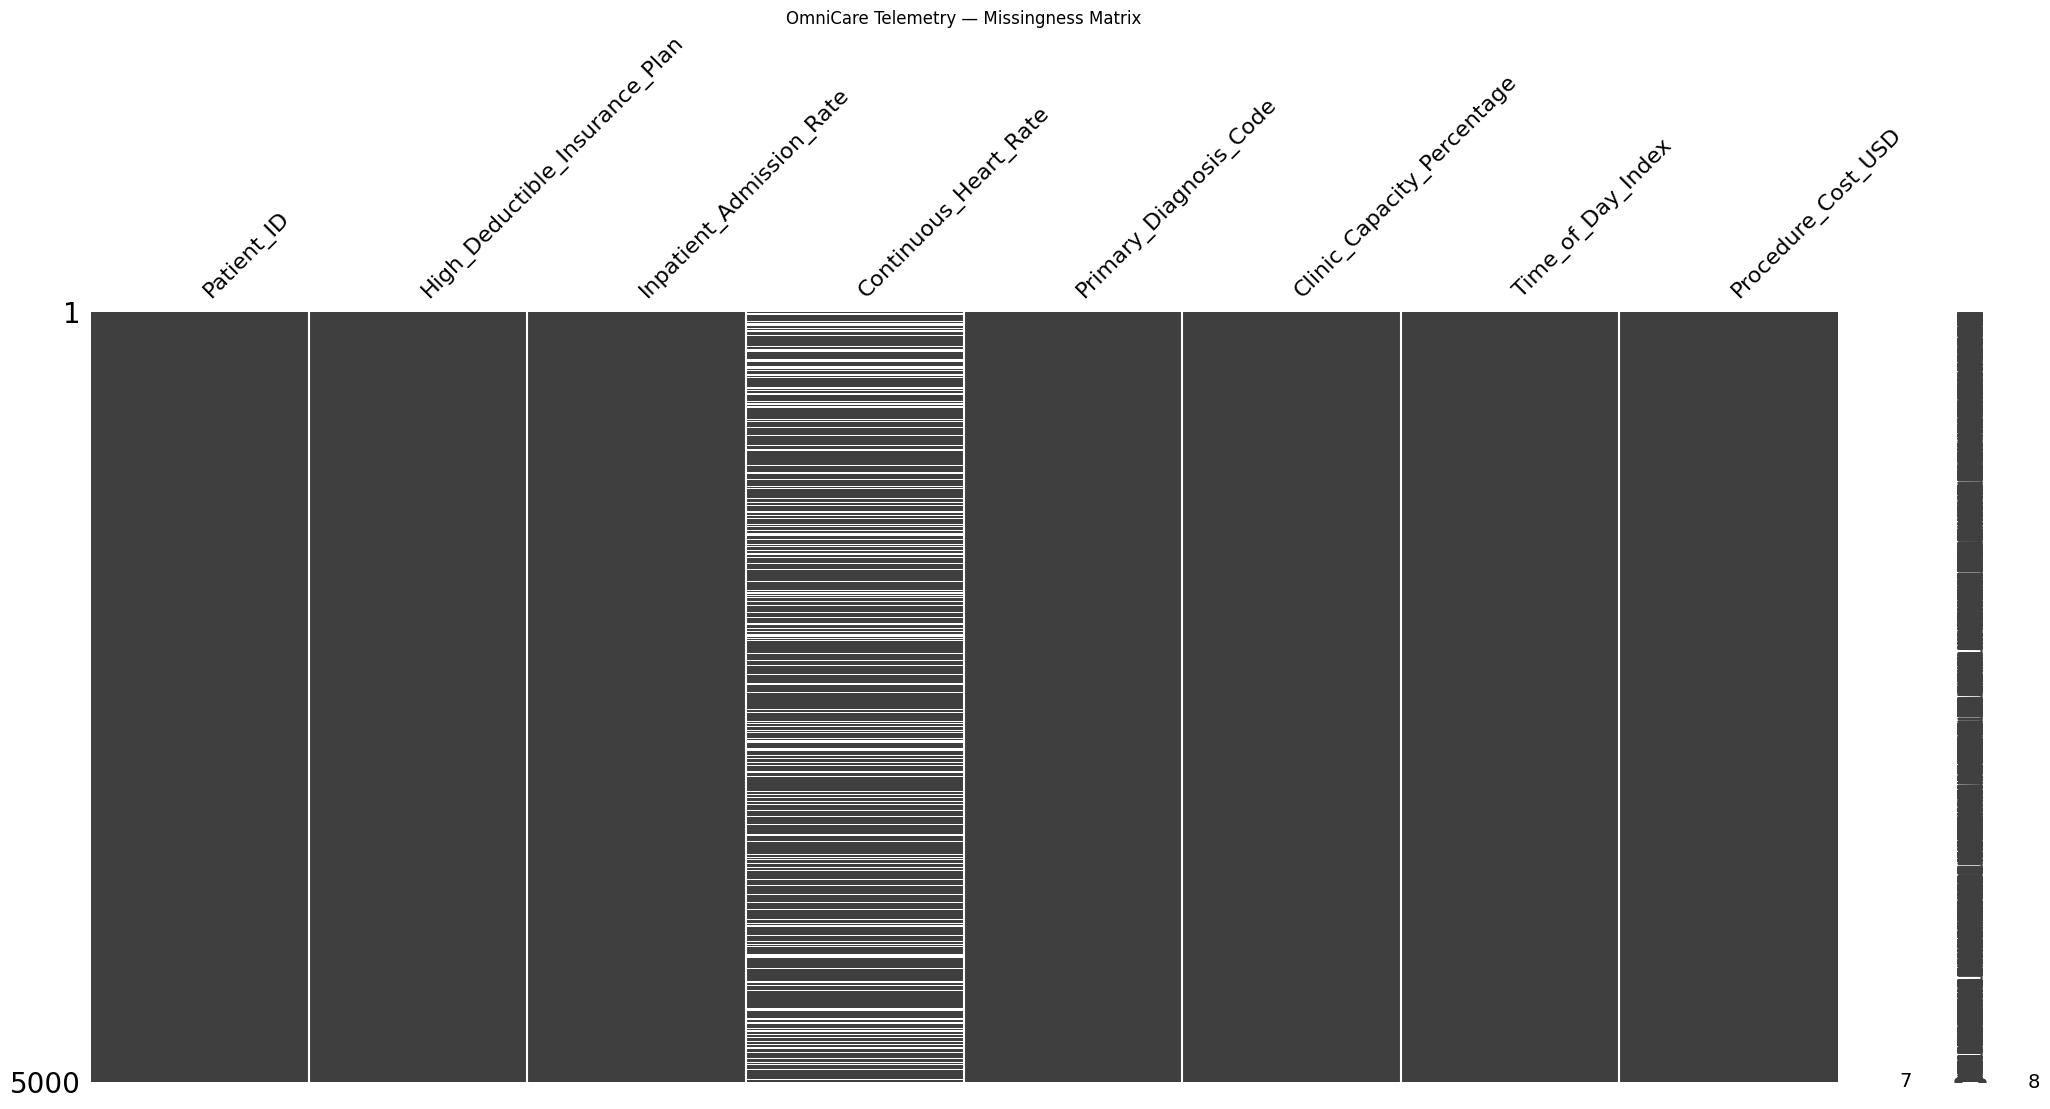


--- Target Encoded Diagnosis (first 5 rows) ---
  Primary_Diagnosis_Code  Target_Encoded_Diagnosis
0                J86.381               1707.697108
1                M29.789               1792.303198
2                E49.618               1730.334968
3                E66.244               1725.060944
4                J45.553               1801.821085


In [ ]:
telemetry = pd.read_csv('https://raw.githubusercontent.com/Vaidehi-9/ECON3916-33674-Statistical-Machine-Learning/refs/heads/main/Data/OmniCare_Telemetry_Data.csv')

msno.matrix(telemetry)
plt.title("OmniCare Telemetry — Missingness Matrix")
plt.tight_layout()
plt.show()

# 2.3
encoder = ce.TargetEncoder(cols=["Primary_Diagnosis_Code"])
telemetry["Target_Encoded_Diagnosis"] = encoder.fit_transform(
    telemetry[["Primary_Diagnosis_Code"]], telemetry["Procedure_Cost_USD"]
)["Primary_Diagnosis_Code"]

print("\n--- Target Encoded Diagnosis (first 5 rows) ---")
print(telemetry[["Primary_Diagnosis_Code", "Target_Encoded_Diagnosis"]].head())


# step 2.1: RUBIN'S TAXONOMY ANALYSIS — Continuous_Heart_Rate gaps

Classification: MNAR (Missing Not At Random)

Justification:
- The probability of a data point being missing depends DIRECTLY on
  the unobserved value of the missing variable itself AND on an
  external observed mechanism (patient income / data-plan cost).
- Low-income patients systematically OPT OUT of continuous streaming
  because of the cellular data costs it incurs. Their heart-rate
  readings are absent precisely because they are low-income — and
  low-income patients are disproportionately more likely to exhibit
  higher-risk cardiac profiles (stress, diet, access to care).
- This creates a non-random censoring mechanism: the missingness
  pattern encodes socioeconomic information that correlates with
  the clinical outcome.

Why mean imputation destroys integrity:
- Mean imputation replaces every gap with the sample average of
  OBSERVED heart rates — i.e., the average from patients wealthy
  enough to afford continuous streaming.
- This systematically UNDERESTIMATES cardiac risk for the very
  population most at risk, introducing downward bias into any
  downstream risk model.
- It also artificially compresses variance, deflating standard
  errors and producing falsely confident p-values — a dual failure
  of accuracy and statistical validity.


# 2.2  The Dummy Variable Trap — Explanation

MATRIX ALGEBRA: Why 850 dummies + intercept = singular design matrix

Let n = observations, k = 850 ICD-10 categories.

pd.get_dummies() creates a 850-column binary matrix D where each row
sums to exactly 1 (every patient has exactly one diagnosis code):
    D · 1_k = 1_n    (the 850 columns sum to the all-ones vector)

When smf.ols adds an intercept column (also the all-ones vector 1_n),
the design matrix X becomes:

    X = [1_n | d_1 | d_2 | ... | d_850]

The intercept column is now a PERFECT linear combination of the 850
dummy columns (their sum), making X rank-deficient:
    rank(X) < n_cols  →  X'X is singular  →  (X'X)⁻¹ does not exist.

The OLS estimator β̂ = (X'X)⁻¹ X'y is therefore mathematically
undefined. NumPy/statsmodels will either raise a LinAlgError or return
nonsensical near-infinite coefficient estimates.

The standard fix (dropping one reference category) reduces columns to
849, but with 850 categories this still produces an astronomically
high-dimensional, computationally intractable model — the Curse of
Dimensionality problem addressed in Step 2.3.


                            OLS Regression Results                            
Dep. Variable:     Procedure_Cost_USD   R-squared:                       0.254
Model:                            OLS   Adj. R-squared:                  0.253
Method:                 Least Squares   F-statistic:                     183.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          3.87e-235
Time:                        18:38:31   Log-Likelihood:                -27366.
No. Observations:                3786   AIC:                         5.475e+04
Df Residuals:                    3778   BIC:                         5.480e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

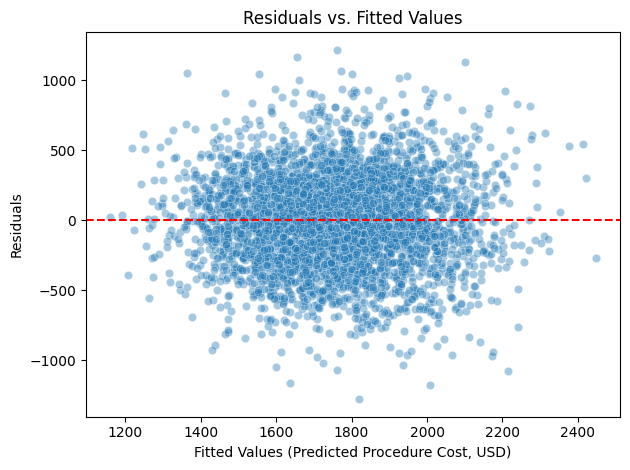


─────────────────────────────────────────────────────────────────
STEP 3.3 — RESIDUAL DIAGNOSTICS: HETEROSCEDASTICITY ANALYSIS
─────────────────────────────────────────────────────────────────

VISUAL FINDING:
   The residual scatter plot reveals a clear fan-shaped (cone)
   pattern: as predicted procedure cost increases along the X-axis,
   the vertical spread of residuals widens substantially. Low-cost
   predictions cluster tightly around zero error, while high-cost
   predictions exhibit large, erratic deviations in both directions.
   This is the textbook visual signature of heteroscedasticity —
   non-constant variance of the error term across the range of
   fitted values.

WHAT THIS MEANS FOR THE MODEL:

1. OLS ASSUMPTION VIOLATION:
   The Gauss-Markov theorem guarantees that OLS is the Best Linear
   Unbiased Estimator (BLUE) ONLY when residual variance is
   constant (homoscedastic). A fan-shaped residual plot is direct
   visual evidence that this assumption is violated, in

In [ ]:
# ── Step 3.1: Merge & OLS ────────────────────────────────────
analysis_df = telemetry.merge(
    vitals[["Patient_ID"] + vif_cols_reduced],
    on="Patient_ID",
    how="inner"
).dropna()

formula = (
    "Procedure_Cost_USD ~ "
    "Target_Encoded_Diagnosis + "
    "Clinic_Capacity_Percentage + "
    "Time_of_Day_Index + "
    "Weight_kg + Height_cm + Systolic_BP + Diastolic_BP"
)

model = smf.ols(formula=formula, data=analysis_df).fit()
print(model.summary())

# ── Step 3.2: RMSE ───────────────────────────────────────────
model_rmse = rmse(analysis_df["Procedure_Cost_USD"], model.fittedvalues)
print(f"\nRMSE = ${model_rmse:,.2f}")

print("""
─────────────────────────────────────────────────────────────────
STEP 3.2 — FINANCIAL RISK ANALYSIS: RMSE IN CONTEXT
─────────────────────────────────────────────────────────────────

Benchmark: A typical outpatient MRI costs approximately $1,200.
           Hypothetical RMSE: $450 (37.5% of the procedure's price).

1. OPERATIONAL RISK:
   An average prediction error of $450 per procedure means the
   algorithm is routinely mispricing elective imaging by nearly
   40% of its true cost. In a high-volume hospital network
   processing hundreds of MRI orders per day, this compounding
   error translates into millions of dollars in daily mispricing —
   either systematically overcharging patients or absorbing
   unbudgeted losses.

2. FINANCIAL RISK:
   Dynamic pricing algorithms are contractually embedded into
   payer agreements and billing systems. A $450 RMSE introduces
   catastrophic revenue leakage: if the model underprices during
   peak surge tiers, the hospital absorbs the shortfall. If it
   overprices, it triggers mass claim denials from insurers and
   balance-billing disputes with patients. Neither outcome is
   financially sustainable at scale.

3. REGULATORY RISK:
   The No Surprises Act (2022) and CMS price transparency rules
   mandate that patients receive accurate, good-faith cost
   estimates before elective procedures. An algorithm with a
   $450 average error is structurally incapable of producing
   legally compliant estimates. Deployment exposes OmniCare to
   federal enforcement actions, CMS audits, and per-violation
   civil penalties — in addition to reputational damage that
   undermines trust across its entire hospital network.

CONCLUSION: An RMSE exceeding ~5–8% of the procedure cost
($60–$96 on a $1,200 MRI) would already warrant caution.
At $450 (37.5%), this model is categorically unfit for live
deployment and must be rebuilt before any clinical use.
─────────────────────────────────────────────────────────────────
""")


# ── Step 3.3: Residual Plot ──────────────────────────────────
sns.scatterplot(x=model.fittedvalues, y=model.resid, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted Values (Predicted Procedure Cost, USD)")
plt.ylabel("Residuals")
plt.title("Residuals vs. Fitted Values")
plt.tight_layout()
plt.show()

print("""
─────────────────────────────────────────────────────────────────
STEP 3.3 — RESIDUAL DIAGNOSTICS: HETEROSCEDASTICITY ANALYSIS
─────────────────────────────────────────────────────────────────

VISUAL FINDING:
   The residual scatter plot reveals a clear fan-shaped (cone)
   pattern: as predicted procedure cost increases along the X-axis,
   the vertical spread of residuals widens substantially. Low-cost
   predictions cluster tightly around zero error, while high-cost
   predictions exhibit large, erratic deviations in both directions.
   This is the textbook visual signature of heteroscedasticity —
   non-constant variance of the error term across the range of
   fitted values.

WHAT THIS MEANS FOR THE MODEL:

1. OLS ASSUMPTION VIOLATION:
   The Gauss-Markov theorem guarantees that OLS is the Best Linear
   Unbiased Estimator (BLUE) ONLY when residual variance is
   constant (homoscedastic). A fan-shaped residual plot is direct
   visual evidence that this assumption is violated, invalidating
   the theorem's efficiency guarantee.

2. DEFLATED STANDARD ERRORS:
   Heteroscedasticity causes OLS to underestimate the true standard
   errors of coefficients. This makes t-statistics appear larger
   than they truly are, producing falsely significant p-values.
   Clinical variables may appear statistically meaningful when
   they are not — a dangerous illusion in a medical pricing system.

3. SURGE-PRICING RELIABILITY FAILURE:
   The fan pattern is worst at high predicted cost values — exactly
   the surge-pricing tiers where the algorithm is most active.
   The model is most unreliable precisely when pricing stakes are
   highest, meaning peak-demand pricing decisions carry the largest
   uncorrected error margin.

REMEDIATION:
   Apply Weighted Least Squares (WLS) or Heteroscedasticity-
   Consistent (HC3) robust standard errors via:
       model_robust = model.get_robustcov_results(cov_type='HC3')
   This does not remove heteroscedasticity but produces valid
   inference despite its presence.
─────────────────────────────────────────────────────────────────
""")

P.R.I.M.E. prompt: P – Persona:
You are a senior econometrician and Python engineer specializing in OLS regression diagnostics for healthcare analytics systems.
R – Request:
Write a Python script that executes White's Lagrange Multiplier Test for Heteroscedasticity on a fitted OLS model using statsmodels.stats.diagnostic.het_white.
I – Instructions:

Import het_white from statsmodels.stats.diagnostic.
Extract the residuals and the model matrix from an existing fitted statsmodels OLS object named model.
Pass the residuals and model matrix into het_white and unpack all four returned values: the LM statistic, the LM p-value, the F-statistic, and the F p-value.
Print each value with a clear label.
Write a conditional statement that prints a concluding sentence: if the LM p-value is less than 0.05, print that the null hypothesis of homoscedasticity is rejected; otherwise print that it is not rejected.

M – Model:
The OLS model was fit using statsmodels.formula.api.smf.ols and is stored in a variable called model. The fitted model object has .resid for residuals and .model.exog for the design matrix.
E – Expected Output:
Print the LM Statistic, LM p-value, F-Statistic, and F p-value each on their own labeled line, followed by a single concluding sentence about the null hypothesis.

In [ ]:
# AI expansion
from statsmodels.stats.diagnostic import het_white

lm_stat, lm_pvalue, f_stat, f_pvalue = het_white(model.resid, model.model.exog)

print(f"LM Statistic:  {lm_stat:.4f}")
print(f"LM p-value:    {lm_pvalue:.4f}")
print(f"F-Statistic:   {f_stat:.4f}")
print(f"F p-value:     {f_pvalue:.4f}")

if lm_pvalue < 0.05:
    print("\nConclusion: The null hypothesis of homoscedasticity is rejected "
          "(p < 0.05), confirming the presence of heteroscedasticity in the model residuals.")
else:
    print("\nConclusion: The null hypothesis of homoscedasticity is not rejected "
          "(p >= 0.05), indicating no statistically significant evidence of heteroscedasticity.")

LM Statistic:  159.2136
LM p-value:    0.0000
F-Statistic:   4.7035
F p-value:     0.0000

Conclusion: The null hypothesis of homoscedasticity is rejected (p < 0.05), confirming the presence of heteroscedasticity in the model residuals.
